In [ ]:
# imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
import seaborn as sns
import gmpy2 as gm

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['text.usetex'] = False
npa= np.array

In [5]:
#import fitted params generated from jupyter notebook "FitModels_Experiment1"

directory_fits = '/Users/mac/Documents/python/ForagingByRichness/reviews/fits_richness/'
#partial dataset
opt_QL= pd.read_csv(directory_fits+'RLParams.csv') 
opt_QL_ab= pd.read_csv(directory_fits+'RLabParams.csv') 
opt_QL_abck = pd.read_csv(directory_fits+'RLabckParams.csv')
#opt_QLarck = pd.read_csv(directory_fits+'RLarckParams.csv')
opt_FOR= pd.read_csv(directory_fits+'FORParams.csv') 

opt_FOR_ab= pd.read_csv(directory_fits+'FORabParams.csv') 
opt_FOR_abck = pd.read_csv(directory_fits+'FORabckParams.csv')

opt_DBM = pd.read_csv(directory_fits+'DBMParams.csv')
opt_EXP_DBM= pd.read_csv(directory_fits+'EXP_DBMParams.csv') 
opt_EXP_free= pd.read_csv(directory_fits+'EXP_freeParams.csv') 


In [6]:
def LSE(x): 
    x = np.array(x)
    c=np.max(x)
    return c + np.log(np.sum(np.exp(x - c)))

In [7]:
####### failed convergence handling #######

opt_QL = opt_QL.loc[opt_QL['succ']==True]
opt_QL_ab = opt_QL_ab.loc[opt_QL_ab['succ']==True]
opt_QL_abck = opt_QL_abck.loc[opt_QL_abck['succ'] == True]

opt_FOR = opt_FOR.loc[opt_FOR['succ']==True]
opt_FOR_ab = opt_FOR_ab.loc[opt_FOR_ab['succ']==True]
opt_FOR_abck = opt_FOR_abck.loc[opt_FOR_abck['succ'] == True]

opt_DBM = opt_DBM.loc[opt_DBM['succ']==True]
opt_EXP_free = opt_EXP_free.loc[opt_EXP_free['succ']==True]
opt_EXP_DBM = opt_EXP_DBM.loc[opt_EXP_DBM['succ']==True]

#ne prends que les sujets en commun
subs = [sub for sub in (opt_FOR['sub'].unique()) if sub in opt_QL['sub'].unique() and sub in opt_FOR_abck['sub'].unique() and sub in opt_QL_abck['sub'].unique() and sub in opt_FOR_ab['sub'].unique() and sub in opt_QL_ab['sub'].unique() and sub in opt_EXP_free['sub'].unique() and sub in opt_EXP_DBM['sub'].unique()]


#### Figures layout

In [8]:
Fcol='mediumseagreen'
Qcol='darkkhaki'

tick_fontsize = 15  
Fcol='mediumseagreen'
Qcol='darkkhaki'
#col = [Qcol,'green','red','blue','yellow','purple',Fcol,'magenta','black','grey']
col = [Qcol,'green','cyan',Fcol,'magenta','blue','purple','grey','black']

dot_size = 160

font = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }

yfont = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        'size': 17,
        }
xfont = {'family': 'arial',
         
        'color':  'black',
        'weight': 'normal',
        'size': 17,
        }

def set_global_plot_style():
    

    # Set global rcParams
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams['font.family'] = 'arial'
    plt.rcParams['legend.fontsize'] = xfont['size']
    plt.rcParams['legend.frameon'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.major.size'] = 2
    plt.rcParams['ytick.major.size'] = 2
    plt.rcParams['xtick.major.width'] = 1.5
    plt.rcParams['ytick.major.width'] = 1.5
    plt.rcParams['xtick.labelsize'] = tick_fontsize
    plt.rcParams['ytick.labelsize'] = tick_fontsize
    plt.rcParams['axes.labelsize'] = xfont['size']
    plt.rcParams['axes.labelcolor'] = xfont['color']
    plt.rcParams['axes.titleweight'] = font['weight']
    plt.rcParams['axes.titlesize'] = font['size']
    plt.rcParams['axes.titlecolor'] = font['color']
    plt.rcParams['svg.fonttype'] = 'none'
    


# Apply the global style
set_global_plot_style()

#### Loglikelihood plot

Text(0, 0.5, '-log likelihood')

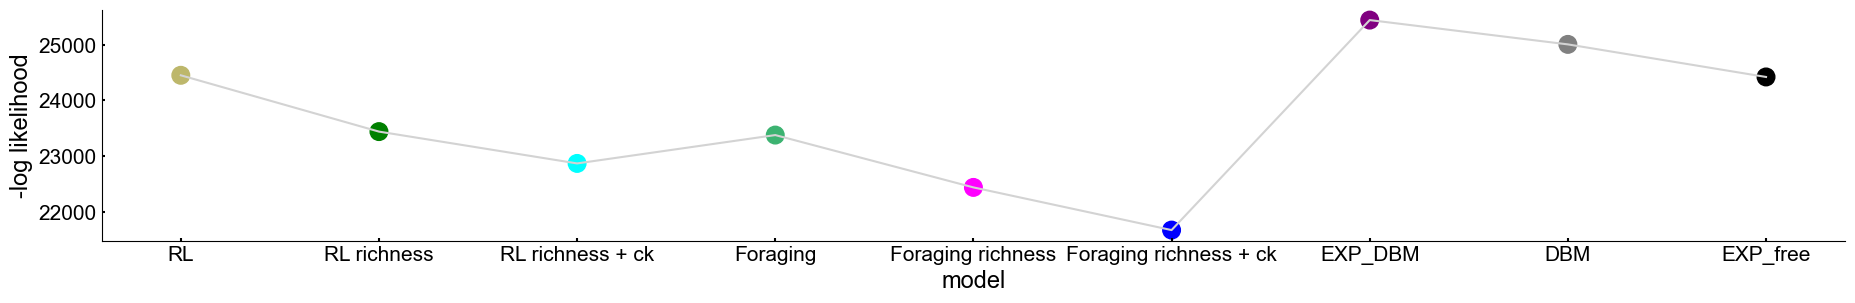

In [ ]:
models = ['RL', 'RL richness','RL richness + ck', 'Foraging', 'Foraging richness', 'Foraging richness + ck', 'EXP_DBM','DBM','EXP_free']
y = [opt_QL['likelihood'].sum(),opt_QL_ab['likelihood'].sum(),opt_QL_abck['likelihood'].sum(), opt_FOR['likelihood'].sum(), opt_FOR_ab['likelihood'].sum(),opt_FOR_abck['likelihood'].sum(),opt_EXP_DBM['likelihood'].sum(),opt_DBM['likelihood'].sum(),opt_EXP_free['likelihood'].sum()]

plt.figure(figsize=(22.5, 3))
plt.scatter(models, y, color=col, s=dot_size)
plt.plot(models,y, c='lightgrey' )

#set labels
plt.xlabel("model",fontdict=xfont)  
plt.ylabel("-log likelihood",fontdict=yfont) 


#### AIC plot

In [9]:
#compute AIC

def AIC(ll, k):
    AIC = 2*k  + 2*ll
    return AIC

AIC_QL = AIC(opt_QL['likelihood'].sum(), 2*len(opt_QL))
AIC_QL_ab = AIC(opt_QL_ab['likelihood'].sum(), 4*len(opt_QL_ab))
AIC_QL_abck= AIC(opt_QL_abck['likelihood'].sum(), 6*len(opt_QL_abck))

AIC_FOR = AIC(opt_FOR['likelihood'].sum(), 3*len(opt_FOR))
AIC_FOR_ab = AIC(opt_FOR_ab['likelihood'].sum(), 5*len(opt_FOR_ab))
AIC_FOR_abck = AIC(opt_FOR_abck['likelihood'].sum(), 7*len(opt_FOR_abck))

AIC_DBM = AIC(opt_DBM['likelihood'].sum(), 2*len(opt_DBM))
AIC_EXP_DBM = AIC(opt_EXP_DBM['likelihood'].sum(), 2*len(opt_EXP_DBM))
AIC_EXP_free = AIC(opt_EXP_free['likelihood'].sum(), 4*len(opt_EXP_free))


(45000.0, 51000.0)

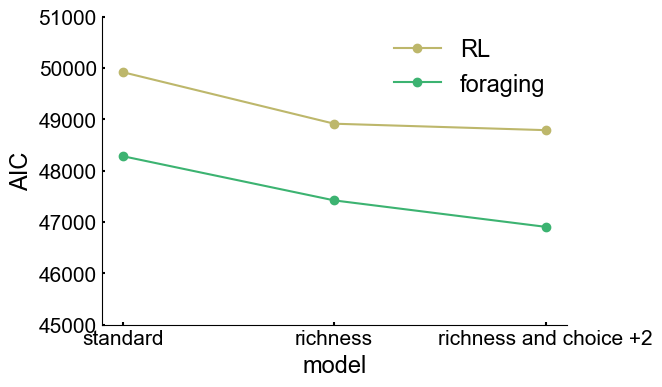

In [ ]:
y1 = [AIC_QL,AIC_QL_ab,AIC_QL_abck]
y2 = [ AIC_FOR,AIC_FOR_ab, AIC_FOR_abck]

#plot
modelsRLFOR = ['standard', 'richness', 'richness and choice +2']
plt.figure(figsize=(6, 4))
#plt.scatter(models, y1, color=col, s=dot_size)
plt.plot(modelsRLFOR,y1, c= Qcol, marker = 'o', label = 'RL' )
plt.plot(modelsRLFOR,y2, c = Fcol, marker = 'o', label = 'foraging')

#set labels
plt.xlabel("model",fontdict=xfont)  
plt.ylabel("AIC",fontdict=yfont) 
plt.legend()
plt.ylim(45000,51000)
#plt.savefig("AICs_RL_FOR_richness.pdf")

#### STATS

In [10]:
def delta_AIC(model_aic):
    delta_AIC = model_aic - min(AIC_QL, AIC_FOR)
    return delta_AIC

In [13]:

print('LL QL =' ,round(opt_QL['likelihood'].sum()))
print('LL foraging =' ,round(opt_FOR['likelihood'].sum()))
print('AIC QL:', round(AIC_QL))
print( 'AIC FOR:', round(AIC_FOR))


print('-----------------------')

delta_AIC_QL = delta_AIC(AIC_QL)
delta_AIC_FOR = delta_AIC(AIC_FOR)
#delta_AIC_EXP_DBM = delta_AIC(AIC_EXP_DBM)
#delta_AIC_EXP_free = delta_AIC(AIC_EXP_free)

print('delta_AIC_FOR:', delta_AIC_FOR, '/////', 'delta_AIC_QL:', delta_AIC_QL)

print('-----------------------')

relative_ll_FOR = gm.exp(-0.5*delta_AIC_FOR)
relative_ll_QL = gm.exp(-0.5*delta_AIC_QL)

#relative_ll_EXP_DBM = gm.exp(-0.5*delta_AIC_EXP_DBM)
#relative_ll_EXP_free = gm.exp(-0.5*delta_AIC_EXP_free)
print('relative likelihood FOR:', relative_ll_FOR, '/////', 'relative likelihood QL:', relative_ll_QL)

print('-----------------------')

Aikake_w_FOR = relative_ll_FOR / (relative_ll_FOR + relative_ll_QL)
Aikake_w_QL = relative_ll_QL / (relative_ll_FOR + relative_ll_QL)
print('Aikake_w_FOR:', Aikake_w_FOR, '/////', 'Aikake_w_QL:', Aikake_w_QL)

LL QL = 24450
LL foraging = 23378
AIC QL: 49917
AIC FOR: 48281
-----------------------
delta_AIC_FOR: 0.0 ///// delta_AIC_QL: 1636.2643950998536
-----------------------
relative likelihood FOR: 1.0 ///// relative likelihood QL: 4.8944188999528509e-356
-----------------------
Aikake_w_FOR: 1.0 ///// Aikake_w_QL: 4.8944188999528509e-356


# Figure for paper

Let's visualize the parameters

In [ ]:
def ql(theta,df):

    sideList= df['choice'].tolist()
    rewardList = df['reward'].tolist()
    betas = []
    mus = []
    Q0 = []
    Q1 = []
    karm= max(sideList)+1
    Qvalue = np.zeros(karm)#+(1/karm) 

    alpha = theta[0]
    beta0 = theta[1]
    #rho_0 =  theta[4]
    probList=[]

    for i in range (len(rewardList)):
        arm = int(sideList[i]) 

        beta = beta0
        betas.append(beta)
        Q0.append(Qvalue[0])
        Q1.append(Qvalue[1])
        ##Softmax function
        prob = np.exp((Qvalue[arm]*beta)-LSE(Qvalue*beta))
        for a in range(karm):
            if a == arm:
                Qvalue[a] += alpha*(rewardList[i]-Qvalue[a])
            else:
                Qvalue[a] += 0 #(1/tau)*(rho-Qvalue[a])
        probList.append(prob)
    

        
        ##log likelihood
        #logLike = (np.sum(np.log(npa(probList)+epsilon))) * (-1)
    new_cols = {'probs': probList, 'betas': betas, 'Q0': Q0, 'Q1': Q1}
    new_cols_df = pd.DataFrame(new_cols)
    aug_data = pd.concat([df.reset_index(),new_cols_df],axis = 1)
    return aug_data

In [ ]:
def ql_ab(theta,df):

    sideList= df['choice'].tolist()
    rewardList = df['reward'].tolist()
    betas = []
    mus = []
    Q0 = []
    Q1 = []
    karm= max(sideList)+1
    Qvalue = np.zeros(karm)#+(1/karm) 

    alpha = theta[0]
    beta0 = theta[1]
    alpha_rho = theta[2]
    beta1 = theta[3]
    #rho_0 =  theta[4]

    mu = 0
    probList=[]

    for i in range (len(rewardList)):
        arm = int(sideList[i]) 

        beta = beta0 + beta1*mu
        betas.append(beta)
        mus.append(mu)
        Q0.append(Qvalue[0])
        Q1.append(Qvalue[1])
        ##Softmax function
        prob = np.exp((Qvalue[arm]*beta)-LSE(Qvalue*beta))
        for a in range(karm):
            if a == arm:
                Qvalue[a] += alpha*(rewardList[i]-Qvalue[a])
            else:
                Qvalue[a] += 0 #(1/tau)*(rho-Qvalue[a])
        probList.append(prob)
        
        mu += alpha_rho*(rewardList[i]- mu)

        
        ##log likelihood
        #logLike = (np.sum(np.log(npa(probList)+epsilon))) * (-1)
    new_cols = {'probs': probList, 'betas': betas, 'rhos': mus, 'Q0': Q0, 'Q1': Q1}
    new_cols_df = pd.DataFrame(new_cols)
    aug_data = pd.concat([df.reset_index(),new_cols_df],axis = 1)
    return aug_data

In [ ]:
def for_ab(theta,df):  

    
    sideList= df['choice'].tolist()
    rewardList = df['reward'].tolist()
    
   
    oitOreList= []
    mus = []
    betas = []
    Qoit = []
    #switch/explore = 0, stay/exploit = 1
    for j in range (len(sideList)-1):  
        if sideList[j]==sideList[j+1]:
            oitOreList.append(1)
        else:
            oitOreList.append(0)

    rewardList = rewardList[1:]
    
    

    alpha = theta[0]
    beta0 = theta[1]   
    alpha_rho = theta[2]
    beta1= theta[3]
    rho_0 = theta[4]

    v_oit = 1 #rho_0

    probList=[]
    mu = 0 #rho_0
    for i in range (len(rewardList)):
        oit = oitOreList[i] # oit or ore 
        
        beta = beta0 + beta1*mu
        betas.append(beta)
        mus.append(mu)
        Qoit.append(v_oit)
        
        if oit == 1:
            prob = np.exp((v_oit*beta)-LSE([v_oit*beta, rho_0*beta]))
            probList.append(prob)
            v_oit += alpha*(rewardList[i]-v_oit)

        if oit == 0:
            prob = 1-(np.exp((v_oit*beta)-LSE([v_oit*beta, rho_0*beta])))
            probList.append(prob)
            v_oit = rho_0 + alpha*(rewardList[i]-rho_0) 
        
        mu += alpha_rho*(rewardList[i]- mu)


    ##log likelihood
    #logLike = (np.sum(np.log(npa(probList)+epsilon))) * (-1)
  
    new_cols = {'probs': probList, 'betas': betas, 'rhos': mus, 'Qoit': Qoit}
    new_cols_df = pd.DataFrame(new_cols)
    aug_data = pd.concat([df.reset_index(),new_cols_df],axis = 1)
    return aug_data

In [ ]:
#download data sample named "Experiment1_data" and change dataPath to your local path 
dataPath = "data/all_sub_2ab.pickle" #"data/Experiment1_data.pickle" #

#extract data
with open(dataPath, 'rb') as handle:
    all_sub_2ab = pickle.load(handle)

/var/folders/20/11y1vnk95q39s6c8yyyx446m0000gn/T/ipykernel_58226/1153829416.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  all_sub_2ab = pickle.load(handle)


In [ ]:
def plot_bandit_visualization_RLs(df_vanilla, df_rhos, 
                            label1='vanilla-RL', label2='rhos-RL',
                            color1='darkkhaki', color2='brown',
                            trial_range=None):
    """
    Creates the multi-panel plot to compare a vanilla RL model
    with a rhos-tracking RL model.
    
    - Top: Reward walks and participant choices (shared data).
    - Bottom: Likelihoods, Vanilla Qs, Richness, Richness Qs
    - trial_range: Optional tuple (start_trial, end_trial) to plot a subset of trials.
                   Trials are 1-based and inclusive.
    """
    
    # --- Prepare Data for Plotting ---
    # We use df_vanilla for all the shared participant data (top plot)
    df = df_vanilla.copy()

    # Create a trial array based on the *original* length
    n_trials_original = len(df)
    trials_original = np.arange(1, n_trials_original + 1)
    
    # --- Apply Trial Range Slicing ---
    if trial_range and (trial_range[0] > 1 or trial_range[1] < n_trials_original):
        # Convert 1-based inclusive range to 0-based exclusive slice
        start_idx = max(0, trial_range[0] - 1)      # e.g., trial 1 -> index 0
        end_idx = min(n_trials_original, trial_range[1]) # e.g., trial 100 -> index 100 (for slice)
        
        # Slice all dataframes
        df = df.iloc[start_idx:end_idx].copy()
        df_vanilla = df_vanilla.iloc[start_idx:end_idx].copy()
        df_rhos = df_rhos.iloc[start_idx:end_idx].copy()
        
        # Slice the trials array
        trials = trials_original[start_idx:end_idx]
        
    else:
        # No slicing, use original data
        trials = trials_original
        # df, df_vanilla, df_rhos are already set (as copies or original)

    # Get n_trials for the *plotted* data
    n_trials = len(df)
    if n_trials == 0:
        print("No trials to plot for the given range.")
        return
        
    # Define colors for choices
    choice_colors = {0: 'C0', 1: 'C1'} # Arm 1 (choice 0) = Blue, Arm 2 (choice 1) = Orange
    df['choice_color'] = df['choice'].map(choice_colors)

    # Define colors and markers for rewards
    reward_colors = {1: 'green', 0: 'red'}
    reward_markers = {1: '|', 0: '|'} # Use '|' for both, color distinguishes
    
    df['reward_color'] = df['reward'].map(reward_colors)
    df['reward_marker'] = df['reward'].map(reward_markers)

    # --- Create the Figure and Subplots ---
    
    fig = plt.figure(figsize=(10, 12)) # Adjusted figure height for 5 plots

    # Use GridSpec for 5 plots in the new order
    gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.2)
    
    ax_top = fig.add_subplot(gs[0])
    ax_probs = fig.add_subplot(gs[1], sharex=ax_top) # Probabilities
    ax_qvals1 = fig.add_subplot(gs[2], sharex=ax_top) # Q-Values (Model 1)
    ax_rhos = fig.add_subplot(gs[3], sharex=ax_top) # Rhos
    #ax_qvals2 = fig.add_subplot(gs[3], sharex=ax_top) # Q-Values (Model 2)
    
    # --- 1. Top Plot (Reward Walks & Choices) ---
    ax_top.set_title(f'Example participant (Trials {trials[0]} to {trials[-1]})', fontsize=16)
    # Plot the reward walks
    ax_top.plot(trials, df['arm1'], color='C0', label='arm 1', alpha=0.7)
    ax_top.plot(trials, df['arm2'], color='C1', label='arm 2', alpha=0.7)
    
    # Overlay participant choices (dots at y=1.1)
    ax_top.scatter(
        trials,
        [1.1] * n_trials,
        c=df['choice_color'],
        marker='.',
        s=50,
        label='choice (1=blue, 2=orange)',
        zorder=3
    )
    
    # Overlay reward indicators (ticks/crosses at y=1.15, just above choices)
    for reward_val, marker, color in zip([1, 0], ['|', '|'], ['green', 'red']):
        # Create a boolean mask for the reward value
        reward_mask = (df['reward'] == reward_val)
        # Apply this mask to our 'trials' array (which is now sliced)
        reward_trials_to_plot = trials[reward_mask]
        
        ax_top.scatter(
            reward_trials_to_plot,
            [1.15] * len(reward_trials_to_plot), # Use the length of the filtered array
            marker=marker,
            color=color,
            s=100, # Increased size to make '|' visible
            linewidth=1.5,
            label=f'reward: {reward_val}',
            zorder=4
        )
    
    ax_top.set_ylabel('reward probability', fontsize=14)
    ax_top.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Move legend outside to avoid overlap
    #ax_top.grid(True, linestyle='--', alpha=0.5)
    ax_top.set_ylim(0, 1.25) # Extend ylim to 1.25 to accommodate reward markers
    
    # --- 2. Choice Probability Plot ('probs') - Comparison ---
    
    # Capture the line artists (proxy artists) for the figure legend
    line_m1, = ax_probs.plot(trials, df_vanilla['probs'], color=color1, label=label1)
    line_m2, = ax_probs.plot(trials, df_rhos['probs'], color=color2, label=label2)
    ax_probs.axhline(0.5, color='black', linestyle=':', label=False)
    ax_probs.set_ylabel(r'$p(\text{choice} |\theta )$', fontsize=12)
    ax_probs.set_ylim(0, 1)
    #ax_probs.grid(True, linestyle='--', alpha=0.5)
    # Add small legend for chance line
    #ax_probs.legend(handles=[ax_probs.get_lines()[2]], loc='upper left') 

    # --- 3. Q-Values Plot (Model 1) ---
    ax_qvals1.plot(trials, df_vanilla['Q0'], color=color1, label=f'Q1', linestyle='-')
    ax_qvals1.plot(trials, df_vanilla['Q1'], color=color1, label=f'Q2', linestyle='--')
    ax_qvals1.plot(trials, df_rhos['Q0'], color=color2, linestyle='-')
    ax_qvals1.plot(trials, df_rhos['Q1'], color=color2, linestyle='--')
    ax_qvals1.set_ylabel(r'Q-values', fontsize=14)
   # ax_qvals1.grid(True, linestyle='--', alpha=0.5)
    ax_qvals1.legend(loc='upper left') # Add legend to distinguish Q0/Q1

    # --- 4. Rhos Plot (Model 2 only) ---
    ax_rhos.plot(trials, df_rhos['rhos'], color=color2)
    ax_rhos.set_ylabel('richness', fontsize=14) # <-- Updated Y-label
    #ax_rhos.grid(True, linestyle='--', alpha=0.5)
    ax_rhos.legend(loc='upper left')
    ax_rhos.set_xlabel('trial number', fontsize=14)

    # --- 5. Q-Values Plot (Model 2) ---

    # ax_qvals2.set_ylabel(f'Q-values', fontsize=12)
    # ax_qvals2.grid(True, linestyle='--', alpha=0.5)
    # ax_qvals2.legend(loc='upper left') # Add legend to distinguish Q0/Q1

    # --- Final Touches ---
    
    # Remove x-axis labels from all but the bottom plot
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_probs.get_xticklabels(), visible=False)
    plt.setp(ax_qvals1.get_xticklabels(), visible=False)
    #plt.setp(ax_qvals2.get_xticklabels(), visible=False)
    
    fig.align_ylabels([ax_top, ax_probs, ax_qvals1, ax_rhos])
    
    # Create a single figure legend for the models, placed at the bottom
    fig.legend(handles=[line_m1, line_m2], 
               labels=[label1, label2],
               loc='lower center', 
               bbox_to_anchor=(0.5, 0.01), # Place it just above the bottom
               ncol=2, 
               fontsize=14)
    
    plt.tight_layout(rect=[0.0, 0.05, 0.88, 0.98]) # Adjust bottom (0 -> 0.05) for fig legend
    #plt.show()


In [ ]:
p = 68 #23: 60 to 175,26,32: 150 to 250, 13
p_trials =all_sub_2ab[p].drop(all_sub_2ab[p].index[0:25])
theta_ql = [opt_QL['alpha'][p],opt_QL['beta'][p]]
ql_data = ql(theta_ql,p_trials)
theta_ql = [opt_QL_ab['alpha'][p],opt_QL_ab['beta'][p],opt_QL_ab['alpha_rho'][p],opt_QL_ab['beta1'][p]]
ql_ab_data = ql_ab(theta_ql,p_trials)
theta_for = [opt_FOR_ab['alpha'][p],opt_FOR_ab['beta'][p],opt_FOR_ab['alpha_rho'][p],opt_FOR_ab['beta1'][p],opt_FOR_ab['rho_0'][p]]
for_ab_data = for_ab(theta_for,p_trials)

/var/folders/20/11y1vnk95q39s6c8yyyx446m0000gn/T/ipykernel_58226/2517210173.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_rhos.legend(loc='upper left')
/var/folders/20/11y1vnk95q39s6c8yyyx446m0000gn/T/ipykernel_58226/2517210173.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.0, 0.05, 0.88, 0.98]) # Adjust bottom (0 -> 0.05) for fig legend


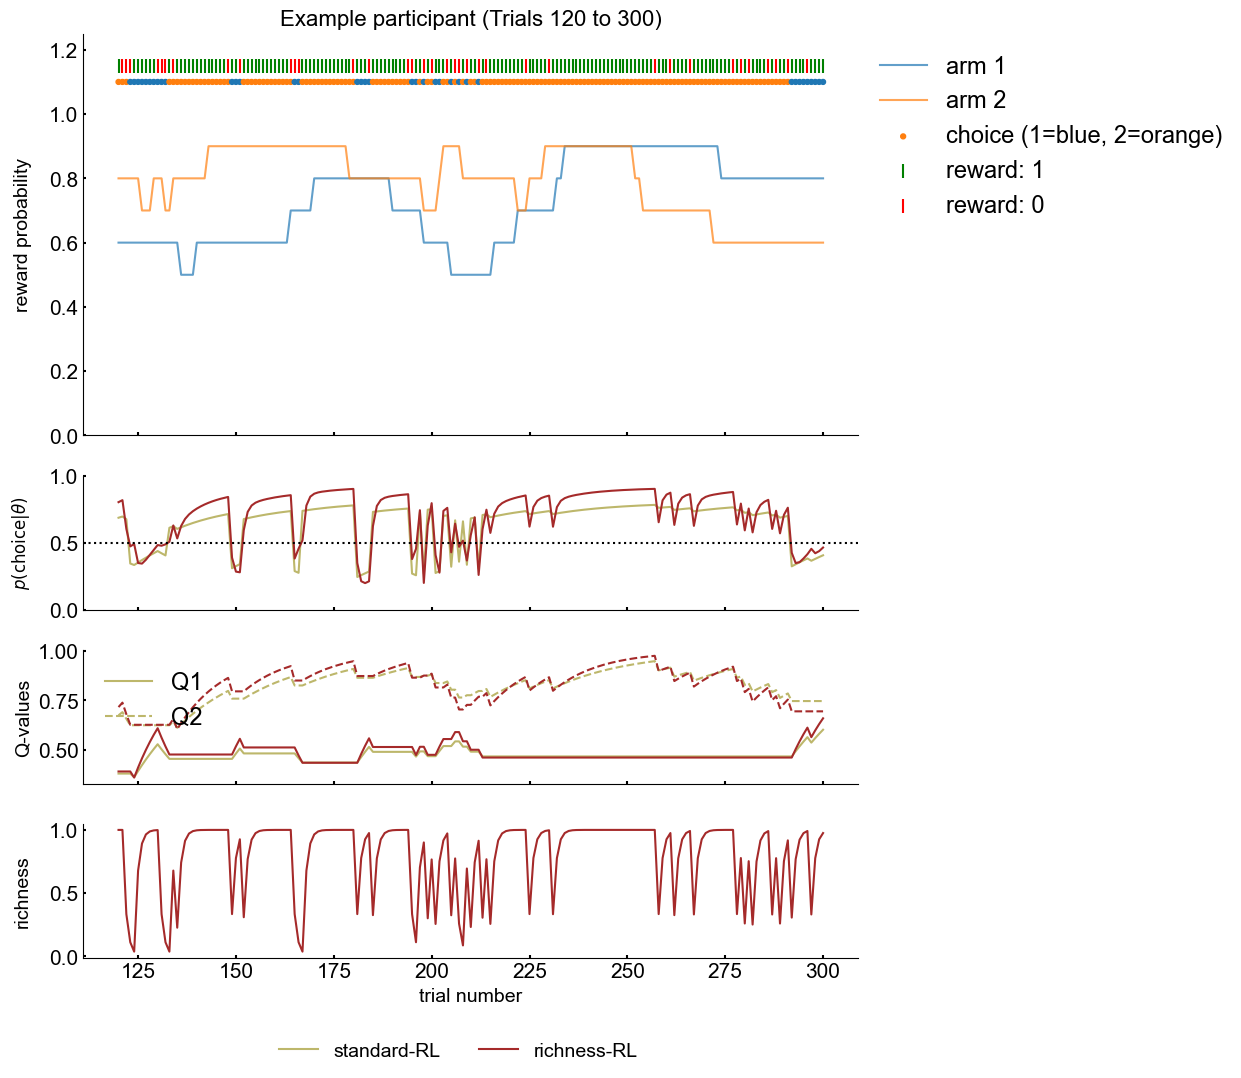

In [ ]:
plot_bandit_visualization_RLs(ql_data,ql_ab_data,'standard-RL','richness-RL',trial_range=(120,350))
# Get a reference to the figure that was just created
fig = plt.gcf() 
    
plt.rcParams['pdf.fonttype'] = 42
# Save it using bbox_inches='tight'
fig.savefig("standard_richness_RL.pdf", bbox_inches="tight")